In [1]:
using Pkg
Pkg.activate("..")
Pkg.resolve()
Pkg.instantiate()
Pkg.precompile()

  Activating project at `c:\Users\camde\.julia\dev\HybridDynamics.jl`
     Project No packages added to or removed from `C:\Users\camde\.julia\dev\HybridDynamics.jl\Project.toml`
    Manifest No packages added to or removed from `C:\Users\camde\.julia\dev\HybridDynamics.jl\Manifest.toml`
Precompiling packages...
   1160.3 ms  ✓ HybridDynamics
  1 dependency successfully precompiled in 1 seconds. 20 already precompiled.


In [2]:
import HybridDynamics as HD

In [3]:
import Plots as plt
using LaTeXStrings

In [4]:
M(q) = [1.0 0.0; 0.0 1.0]
V(q) = q[2]
h(q) = 1 - (q[1]^2+q[2]^2)
∇h(q) = [-2*q[1], -2*q[2]]

∇h (generic function with 1 method)

In [11]:
sysM = HD.MechanicalSystem(M, V; guard=h, normal=∇h, e=0.8)
probM = HD.prob(sysM, [-0.95, 0.0, 0.2, -1.5], (0.0, 15.0))
solM = HD.solve(probM, solver=HD.RK4())

HybridDynamics.MechanicalSol{Vector{Float64}, Vector{Vector{Float64}}, Vector{Vector{Float64}}, HybridDynamics.prob{HybridDynamics.MechanicalSystem{typeof(M), typeof(V), typeof(h), typeof(∇h), HybridDynamics.var"#MechanicalSystem##2#MechanicalSystem##3", Float64}, Vector{Float64}, Tuple{Float64, Float64}}, Vector{Float64}, Vector{Float64}}([0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.060000000000000005, 0.07, 0.08, 0.09  …  14.914579440861617, 14.924579440861617, 14.934579440861617, 14.944579440861617, 14.954579440861616, 14.964579440861616, 14.974579440861616, 14.984579440861616, 14.994579440861616, 15.004579440861615], [[-0.95, 0.0, 0.2, -1.5], [-0.948, -0.01505, 0.2, -1.51], [-0.946, -0.030199999999999998, 0.2, -1.52], [-0.944, -0.04545, 0.2, -1.53], [-0.942, -0.0608, 0.2, -1.54], [-0.94, -0.07625, 0.2, -1.55], [-0.938, -0.09179999999999999, 0.2, -1.56], [-0.9359999999999999, -0.10744999999999999, 0.2, -1.57], [-0.9339999999999999, -0.12319999999999999, 0.2, -1.58], [-0.9319999999999999, -

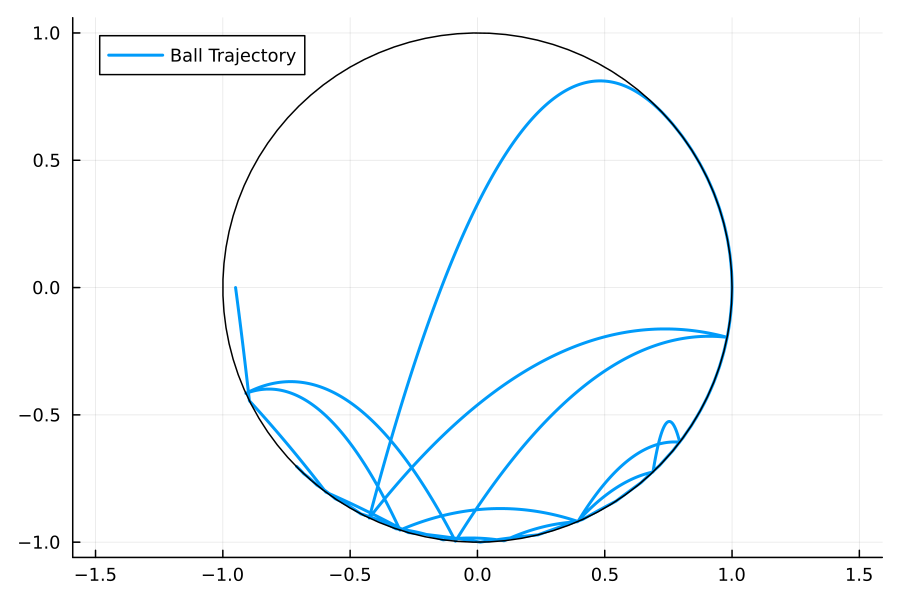

In [12]:
xm = getindex.(solM.x, 1)
ym = getindex.(solM.x, 2)
plt.plot(xm, ym, label="Ball Trajectory", lw=2)
θ = LinRange(0, 2π, 100)
plt.plot!(cos.(θ), sin.(θ), label="", lc=:black, aspect_ratio=1, dpi = 150)

In [7]:
t1 = solM.t[1]
t2 = solM.t[2];

In [8]:
solM(0.11)

4-element Vector{Float64}:
 -0.9279999999999999
 -0.17105
  0.2
 -1.61

In [9]:
solM.event

Float64[]